## step 1 import all required libraries

In [2]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


## STEP 2 — Load and Explore the MNIST Dataset

In [3]:
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# cheek the sahpe of the dataset
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [5]:
import pandas as pd

pd.DataFrame(x_train[0]) # extract pexil value of the first digit

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


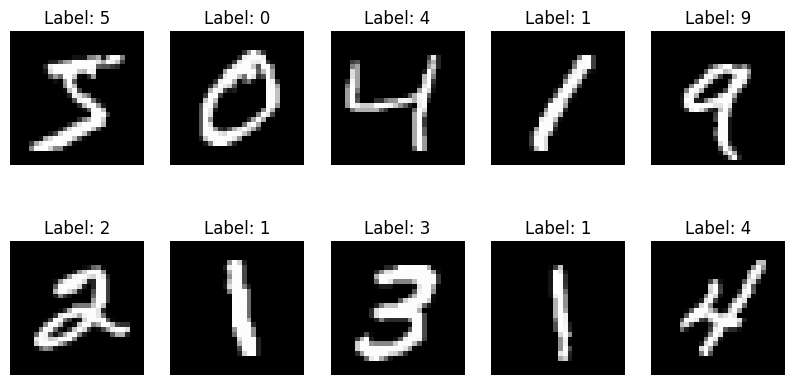

In [6]:
# Visualize Some Sample Images

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show() # This will display 10 sample handwritten digits with their correct labels.


In [7]:
# Quick Label Check
print("First 10 labels:", y_train[:10])



First 10 labels: [5 0 4 1 9 2 1 3 1 4]


## STEP 3 — Data Preprocessing

In [8]:
# Normalize Pixel Values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
print(x_train[0][18]) # cheek normalization of pixel

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.18039216 0.50980395 0.7176471  0.99215686
 0.99215686 0.8117647  0.00784314 0.         0.         0.
 0.         0.         0.         0.        ]


 ## reshaping image for CNN

---




In [10]:

x_train = x_train.reshape(-1, 28, 28, 1) # -1 automatically calculate the sample dataset
x_test = x_test.reshape(-1, 28, 28, 1)

-1 → automatically calculates the number of samples (60,000 for train)

28, 28 → image height and width

1 → number of channels (grayscale)

In [11]:
# cheek the shape after reshaping
print("x_train shape after reshaping:", x_train.shape)
print("x_test shape after reshaping:", x_test.shape)

x_train shape after reshaping: (60000, 28, 28, 1)
x_test shape after reshaping: (10000, 28, 28, 1)


## One-Hot Encode Labels

CNNs use categorical cross-entropy loss, so labels must be one-hot encoded:

Each label is now a 10-dimensional vector

Example: digit 3 → [0 0 0 1 0 0 0 0 0 0]

In [12]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [13]:
# cheek shape after encoding
print("y_train shape after one-hot encoding:", y_train.shape)
print("y_test shape after one-hot encoding:", y_test.shape)

y_train shape after one-hot encoding: (60000, 10)
y_test shape after one-hot encoding: (10000, 10)


# STEP 4 — Build the CNN

 i use Keras Sequential API to create the model.



In [14]:
# Import Required Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

Conv2D → convolutional layer

MaxPooling2D → pooling layer

Dropout → regularization

Flatten → flatten feature maps into a 1D vector

Dense → fully connected layer

In [15]:
# Create a Function to Build Model
def build_model():
    model = Sequential()

    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(2,2),
                     padding='valid', activation='relu',
                     input_shape=(28,28,1)))

    model.add(Conv2D(filters=32, kernel_size=(2,2), strides=(1,1),
                     padding='same', activation='relu'))

    model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

    model.add(Dropout(0.35))

    model.add(Flatten())

    model.add(Dense(256, activation='tanh'))

    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model

## Check Model Summary

In [16]:
model = build_model()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 13, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191,338 (4.54 MB)

 Trainable params: 1,191,338 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

## step 5 train the model with the 3 specified opotimizer
## 1 Train the model  with Adam opotimizer

In [17]:
model_adam = build_model()

model_adam.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9573 - loss: 0.1396 - val_accuracy: 0.9856 - val_loss: 0.0437
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9786 - loss: 0.0682 - val_accuracy: 0.9857 - val_loss: 0.0401
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9840 - loss: 0.0534 - val_accuracy: 0.9902 - val_loss: 0.0322
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0458 - val_accuracy: 0.9880 - val_loss: 0.0402
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9862 - val_loss: 0.0477
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.9890 - val_loss: 0.0386
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0301 -

## Plot Loss Curve for Each Optimizer

###  adam

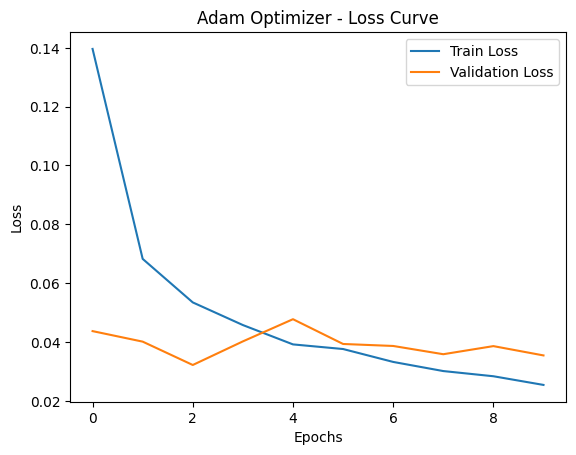

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')

plt.title("Adam Optimizer - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("adam_loss.png")
plt.show()

## 2 Train with Adadelta

In [20]:
model_adadelta = build_model()

model_adadelta.compile(optimizer='adadelta',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_adadelta = model_adadelta.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2406 - loss: 2.2373 - val_accuracy: 0.5476 - val_loss: 2.1564
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4646 - loss: 2.0703 - val_accuracy: 0.6769 - val_loss: 1.9393
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5915 - loss: 1.8153 - val_accuracy: 0.7301 - val_loss: 1.6193
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.6636 - loss: 1.4948 - val_accuracy: 0.7768 - val_loss: 1.2676
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7113 - loss: 1.1984 - val_accuracy: 0.8032 - val_loss: 0.9882
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7458 - loss: 0.9843 - val_accuracy: 0.8234 - val_loss: 0.8010
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7663 - loss: 0.8431 - val_accuracy: 0.8397 - val_loss: 0.6794
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7857 - loss: 0.7487 

## Adadelta loss curve

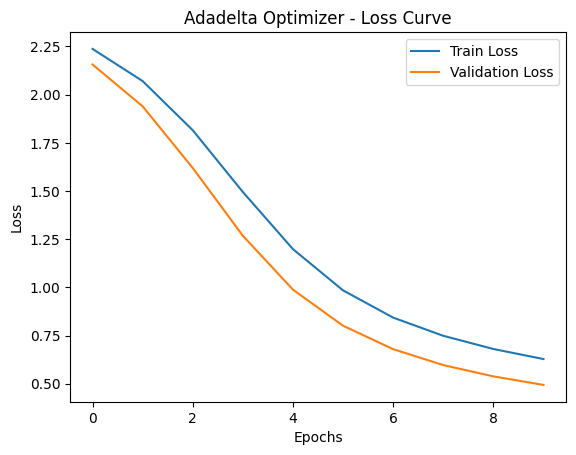

In [22]:
plt.figure()
plt.plot(history_adadelta.history['loss'], label='Train Loss')
plt.plot(history_adadelta.history['val_loss'], label='Validation Loss')

plt.title("Adadelta Optimizer - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("adadelta_loss.png")
plt.show()

## 3 Train  the network also  with SGD

In [23]:
model_sgd = build_model()

model_sgd.compile(optimizer='sgd',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8391 - loss: 0.5159 - val_accuracy: 0.9575 - val_loss: 0.1502
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9467 - loss: 0.1802 - val_accuracy: 0.9724 - val_loss: 0.0932
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9600 - loss: 0.1332 - val_accuracy: 0.9771 - val_loss: 0.0748
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9658 - loss: 0.1109 - val_accuracy: 0.9798 - val_loss: 0.0642
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9700 - loss: 0.0977 - val_accuracy: 0.9798 - val_loss: 0.0638
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9730 - loss: 0.0885 - val_accuracy: 0.9838 - val_loss: 0.0498
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9752 - loss: 0.0810 - val_accuracy: 0.9848 - val_loss: 0.0474
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9759 - loss: 0.0764 -

## SGD loss curve

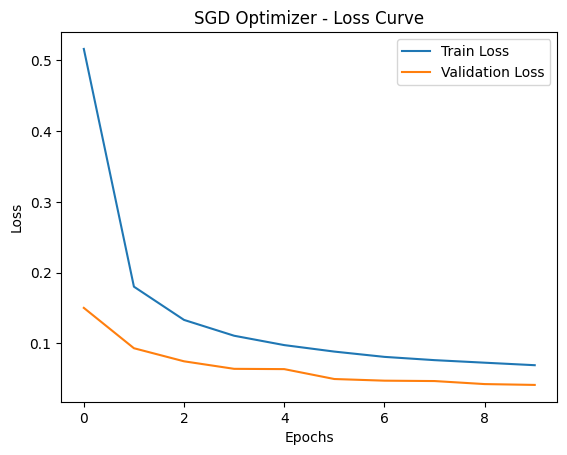

In [24]:
plt.figure()
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')

plt.title("SGD Optimizer - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("sgd_loss.png")
plt.show()

## finally i Compared ALL Optimizers loss  together

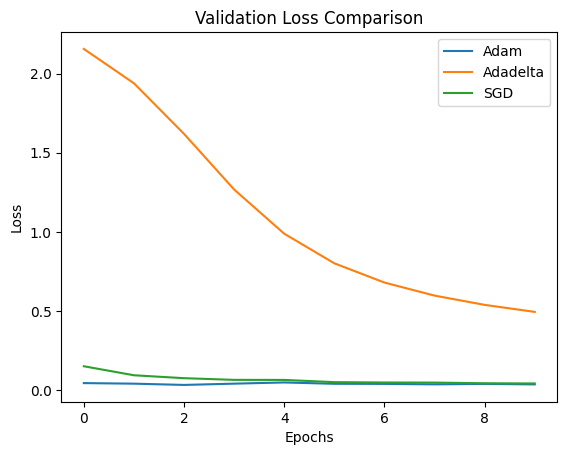

In [25]:
plt.figure()

plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_adadelta.history['val_loss'], label='Adadelta')
plt.plot(history_sgd.history['val_loss'], label='SGD')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("optimizer_loss_comparison.png")
plt.show()

## Accuracy Comparisson for all 3 optimizer

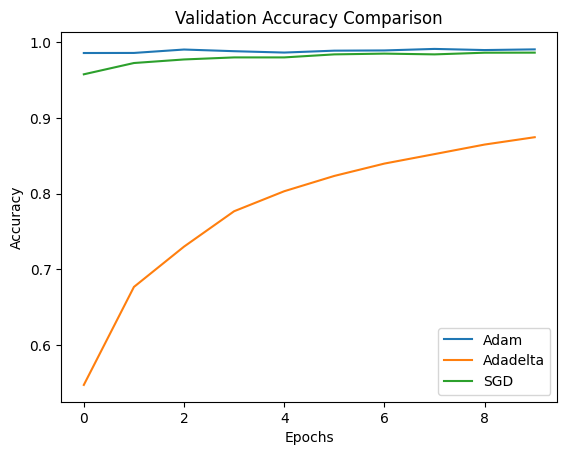

In [26]:
plt.figure()

plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.plot(history_adadelta.history['val_accuracy'], label='Adadelta')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("accuracy_comparison.png")
plt.show()

##  step 6 Evaluate and Visualize Predictions

In [28]:


# Evaluate Adam model
test_loss_adam, test_acc_adam = model_adam.evaluate(x_test, y_test, verbose=0)
print(f"Adam -> Test Loss: {test_loss_adam:.4f}, Test Accuracy: {test_acc_adam:.4f}")
# Evaluate Adadelta model
test_loss_adadelta, test_acc_adadelta = model_adadelta.evaluate(x_test, y_test, verbose=0)
print(f"Adadelta -> Test Loss: {test_loss_adadelta:.4f}, Test Accuracy: {test_acc_adadelta:.4f}")

# Evaluate SGD model
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(x_test, y_test, verbose=0)
print(f"SGD -> Test Loss: {test_loss_sgd:.4f}, Test Accuracy: {test_acc_sgd:.4f}")


Adam -> Test Loss: 0.0354, Test Accuracy: 0.9904
Adadelta -> Test Loss: 0.4939, Test Accuracy: 0.8745
SGD -> Test Loss: 0.0414, Test Accuracy: 0.9861


## From the Above Plot and evalution i observe that adam optimizer  achieved the best accuracy and lowest loss  so it was the best optimizer


## Make Predictions using best model adam


In [30]:

# Predict probabilities for each class
y_pred_probs = model_adam.predict(x_test[:10])

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
# Actual labels
actual_classes = np.argmax(y_test[:10], axis=1)
print("Predicted:", y_pred_classes)
print("Actual   :", actual_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual   : [7 2 1 0 4 1 4 9 5 9]


## Visualize Predictions

It’s nice to see the images with predicted labels:

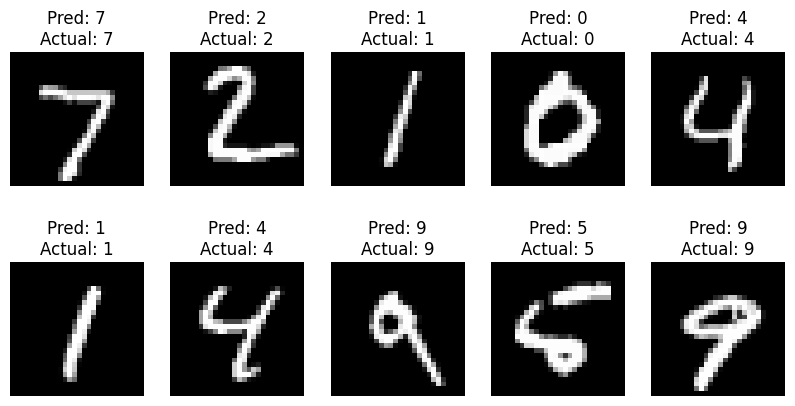

In [31]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')  # reshape to 28x28 for display
    plt.title(f"Pred: {y_pred_classes[i]}\nActual: {actual_classes[i]}")
    plt.axis('off')

plt.show()

## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


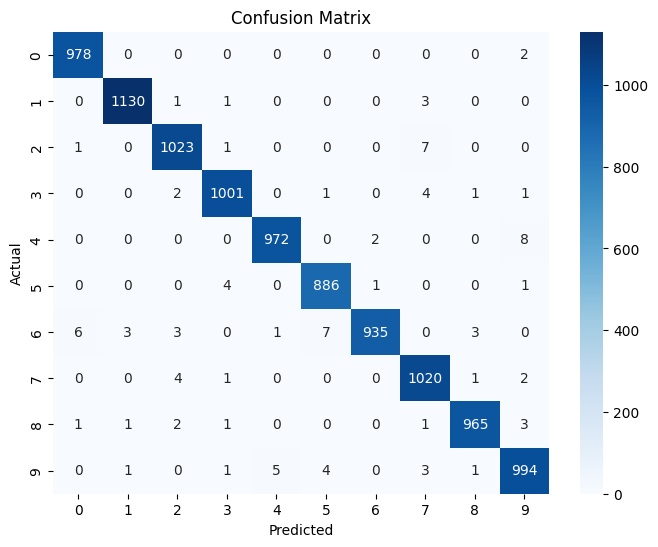

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(model_adam.predict(x_test), axis=1))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




## step 7 Save the Trained Model

In [33]:
# Save Adam model
model_adam.save("cnn_mnist_adam.h5")

# Save Adadelta model
model_adadelta.save("cnn_mnist_adadelta.h5")

# Save SGD model
model_sgd.save("cnn_mnist_sgd.h5")

## Load the Model Later

In [34]:
from tensorflow.keras.models import load_model

# Load Adam model
loaded_adam = load_model("cnn_mnist_adam.h5")

# Evaluate to check it works
test_loss, test_acc = loaded_adam.evaluate(x_test, y_test, verbose=0)
print("Loaded Adam Model -> Test Loss:", test_loss, "Test Accuracy:", test_acc)

Loaded Adam Model -> Test Loss: 0.03542575612664223 Test Accuracy: 0.9904000163078308
